In [72]:
# !pip install umap-learn
# !pip install tensorflow
# pip install torch
%pip install keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import mne

In [2]:
import tensorflow as tf
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
from tensorflow.python.framework.ops import disable_eager_execution


from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
# import seaborn as sns
# import plotly.express as px
import umap.umap_ as umap
# import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer

from keras.utils import to_categorical
import warnings
from keras.layers import Input, Dense, Lambda, Reshape, Flatten, BatchNormalization
from keras.layers import concatenate as concat
from keras.models import Model
from keras import backend as K
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

disable_eager_execution()
print(tf.executing_eagerly())

random_seed=3
random.seed(random_seed)

c:\Users\carlo\Área de Trabalho\ICs\AVC\EEG_Analysis-for-CVA\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False


In [3]:
folder_path = "Dataset/tuh_eeg_abnormal/edf/train/abnormal/01_tcp_ar"

files = os.listdir(folder_path)
raws = []
for file in files[0:10]:
    path = folder_path + '/' + file

    raws.append(mne.io.read_raw_edf(path, preload=True))

Extracting EDF parameters from c:\Users\carlo\Área de Trabalho\ICs\AVC\EEG_Analysis-for-CVA\Dataset\tuh_eeg_abnormal\edf\train\abnormal\01_tcp_ar\aaaaaaaq_s004_t000.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 338999  =      0.000 ...  1355.996 secs...
Extracting EDF parameters from c:\Users\carlo\Área de Trabalho\ICs\AVC\EEG_Analysis-for-CVA\Dataset\tuh_eeg_abnormal\edf\train\abnormal\01_tcp_ar\aaaaaaaq_s005_t001.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 350249  =      0.000 ...  1400.996 secs...
Extracting EDF parameters from c:\Users\carlo\Área de Trabalho\ICs\AVC\EEG_Analysis-for-CVA\Dataset\tuh_eeg_abnormal\edf\train\abnormal\01_tcp_ar\aaaaaaat_s002_t001.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 388249  =      0.000 ...  1552.996 secs...
Extracting EDF parameters from c:\Users\carlo\Área de Trabalho\I

In [4]:
# informações sobre as amostras
raw = raws[9]
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: EEG FP1-REF, EEG FP2-REF, EEG F3-REF, EEG F4-REF, EEG C3-REF, ...
 chs: 36 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 125.0 Hz
 meas_date: 2011-01-01 00:00:00 UTC
 nchan: 36
 projs: []
 sfreq: 250.0 Hz
 subject_info: 3 items (dict)
>

In [5]:
# visualização dos nomes dos canais
raw.ch_names

['EEG FP1-REF',
 'EEG FP2-REF',
 'EEG F3-REF',
 'EEG F4-REF',
 'EEG C3-REF',
 'EEG C4-REF',
 'EEG P3-REF',
 'EEG P4-REF',
 'EEG O1-REF',
 'EEG O2-REF',
 'EEG F7-REF',
 'EEG F8-REF',
 'EEG T3-REF',
 'EEG T4-REF',
 'EEG T5-REF',
 'EEG T6-REF',
 'EEG A1-REF',
 'EEG A2-REF',
 'EEG FZ-REF',
 'EEG CZ-REF',
 'EEG PZ-REF',
 'EEG ROC-REF',
 'EEG LOC-REF',
 'EEG EKG1-REF',
 'EMG-REF',
 'EEG 26-REF',
 'EEG 27-REF',
 'EEG 28-REF',
 'EEG 29-REF',
 'EEG 30-REF',
 'EEG T1-REF',
 'EEG T2-REF',
 'PHOTIC-REF',
 'IBI',
 'BURSTS',
 'SUPPR']

In [6]:
# para selecionar somente alguns canais específicos
# raw.pick(['EEG F3-REF', 'EEG T1-REF'])

# eeg_and_eog = raw.copy().drop_channels(["EMG-REF", "PHOTIC-REF", "IBI", "BURSTS", "SUPPR"])
# print(len(raw.ch_names), "→", len(eeg_and_eog.ch_names))

# raw.pick(['EEG F3-REF', 'EEG T1-REF'])

eeg_set = []
for raw in raws:
    try:
        # eeg = raw.copy().drop_channels(["EMG-REF", "PHOTIC-REF", "IBI", "BURSTS", "SUPPR"])
        eeg = raw.copy().pick(['EEG FP1-REF','EEG FP2-REF','EEG F3-REF','EEG F4-REF','EEG C3-REF','EEG C4-REF','EEG P3-REF','EEG P4-REF','EEG O1-REF','EEG O2-REF','EEG F7-REF','EEG F8-REF','EEG T3-REF','EEG T4-REF','EEG T5-REF','EEG T6-REF','EEG A1-REF','EEG A2-REF','EEG FZ-REF','EEG CZ-REF','EEG PZ-REF'])
        eeg_set.append(eeg)
        print(len(raw.ch_names), "→", len(eeg.ch_names))

    except ValueError:
        pass

30 → 21
30 → 21
30 → 21
36 → 21
36 → 21
30 → 21
36 → 21
36 → 21
30 → 21
36 → 21


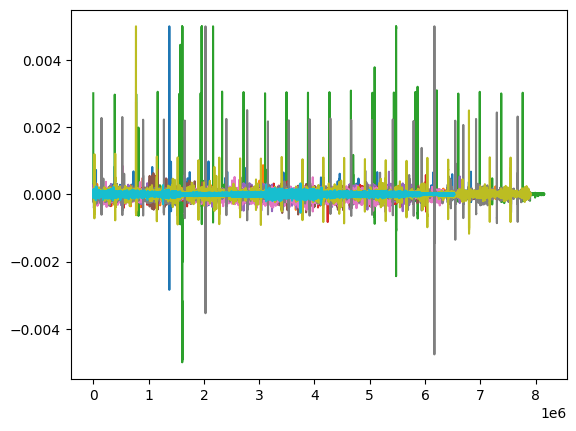

In [18]:
# quantidade de amostras
# print(len(eeg.times))

import matplotlib.pyplot as plt
import numpy as np

###################################################################
## código de teste

# samples = np.array(raw[0][0])

# for i in range(1, 36):
#     # print(raw[i][0])
#     samples = np.vstack([samples, raw[i][0]])

# # print(samples.shape)

# plt.plot(samples[0])
# plt.plot(samples[2])

###################################################################


samples = []
for eeg in eeg_set:
    
    X = np.array(eeg[0][0])

    for i in range(1, 21):
        # X = np.vstack([X, eeg[i][0]])
        X = np.append(X, eeg[i][0])

    # plt.plot(X[0])
    # plt.plot(X[2])
    plt.plot(X)

    samples.append(X)

In [41]:
###################################################################
# scale data
# scaler = StandardScaler().fit(samples.T)
# #scaler = MinMaxScaler().fit(X.T)
# samplesNorm = scaler.transform(samples.T).T

###################################################################
samplesNorm = []
# scale data
for X in samples:
    # print(X)
    X_reshape = X.reshape(-1,1)
    # print(X_reshape)
    # scaler = StandardScaler().fit(X_reshape)
    scaler = MinMaxScaler().fit(X_reshape)
    Xnorm_reshape = scaler.transform(X_reshape)
    # print(Xnorm_reshape)
    Xnorm = np.squeeze(Xnorm_reshape)
    # print(Xnorm)

    samplesNorm.append(Xnorm)


[0.36824594 0.36849888 0.36847942 ... 0.36244771 0.36244771 0.36244771]


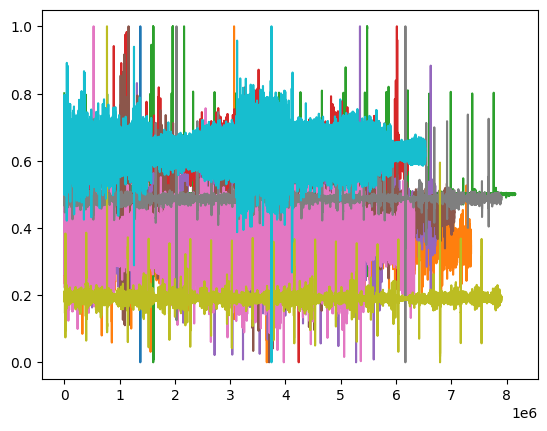

In [ ]:
for Xnorm in samplesNorm:
    # plt.plot(Xnorm[0])
    # plt.plot(Xnorm[2])
    plt.plot(Xnorm)

In [ ]:
#classes
y = np.array([[0],[1]])

(2, 1)
